# **BUILDING NEURAL NETWORKS FROM SCRATCH PART 1**

* [Gradient Descent](https://www.geeksforgeeks.org/machine-learning/gradient-descent-algorithm-and-its-variants/)
* [Implementation of neural network from scratch using NumPy](https://www.geeksforgeeks.org/numpy/implementation-of-neural-network-from-scratch-using-numpy/)


**Example of Email Classification**

Let's consider a record of an email dataset:

| ID | Email Content                | Sender            | Subject Line     | Label |
|----------|-----------------------------|-------------------|------------------|-------|
| 1        | Get free gift cards now!    | spam@example.com  | Exclusive Offer  | 1     |

To classify this email, we will create a feature vector based on the analysis of keywords such as "free" "win" and "offer"

The feature vector of the record can be presented as:
*   "free": Present (1)
*   "win": Absent (0)
*   "offer": Present (1)





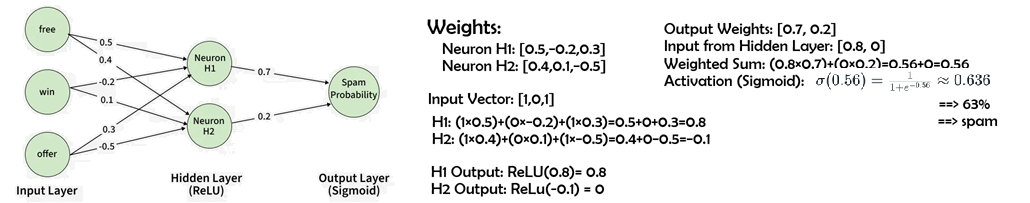

## **1.1. CODING OUR FIRST NEURON: 3 INPUTS**

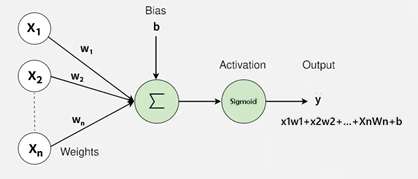

In [ ]:
inputs = [1, 2, 3]
weights = [0.2, 0.8, -0.5]
bias = 2

outputs = (inputs[0]*weights[0] + inputs[1]*weights[1] + inputs[2]*weights[2] + bias)

print(outputs)

2.3


Bias is added to neural networks to allow the activation function to shift, enabling the model to fit data better by adjusting the output even when inputs are zero or minimal

**The Problem Without Bias**
Let’s say you’re building a model to predict whether someone will buy a product based on their age. You’ve got one input (age) and one weight. Your neuron computes:

<div align="center">output = weight × age</div>

Now, what if you need your model to predict that teenagers (let’s say age 15) are likely buyers, but toddlers (age 2) are not? You can adjust the weight all you want, but here’s the issue: the line always passes through zero.

If age = 0, output = 0. Always. No matter what weight you choose.

You can’t shift the line up or down. You can’t say, “Actually, there’s a baseline probability of buying that exists independent of age.” The model is

<br/>

**Enter Bias: The Line Shifter**

<div align="center"> output = weight × age + bias </div>

Suddenly, you can move that line anywhere. You can shift it up so that even younger ages get positive scores. You can shift it down to be more conservative. **Bias gives your neuron the freedom to not be centered at zero.**

<br/>

**The Thermostat Analogy**
The temperature sensor is your input. The heating system responds based on that input. But there’s also a threshold setting — maybe you’ve set it to 68°F. That threshold is your bias. It’s the point at which the system says, “Okay, now I’m turning on the heat,” regardless of how the temperature changes moment to moment.

Without that threshold (bias), the heater would only respond proportionally to temperature. It couldn’t “decide” when to kick in. The bias is what gives it a reference point, a baseline from which to act.

That’s what bias does in a neural network. It’s the reference point. The place where the neuron says, “Here’s where I start caring.”

## **1.2. CODING OUR FIRST LAYER**

<img src="https://drive.google.com/uc?id=1qd1ynY2szOTSyAg5roM-bQYCm4-gShwe" width="600" alt="neuron_1">


In [ ]:
inputs = [1, 2, 3, 2.5]

weights = [
    [0.2, 0.8, -0.5, 1],
    [0.5, -0.91, 0.26, -0.5],
    [-0.26, -0.27, 0.17, 0.87]
]

weights1 = weights[0] #LIST OF WEIGHTS ASSOCIATED WITH 1ST NEURON : W11, W12, W13, W14
weights2 = weights[1] #LIST OF WEIGHTS ASSOCIATED WITH 2ND NEURON : W21, W22, W23, W24
weights3 = weights[2] #LIST OF WEIGHTS ASSOCIATED WITH 3RD NEURON : W31, W32, W33, W34

biases = [2, 3, 0.5]

outputs = [
 # Neuron 1:
 inputs[0]*weights1[0] +
 inputs[1]*weights1[1] +
 inputs[2]*weights1[2] +
 inputs[3]*weights1[3] + biases[0],
 # Neuron 2:
 inputs[0]*weights2[0] +
 inputs[1]*weights2[1] +
 inputs[2]*weights2[2] +
 inputs[3]*weights2[3] + biases[1],
 # Neuron 3:
 inputs[0]*weights3[0] +
 inputs[1]*weights3[1] +
 inputs[2]*weights3[2] +
 inputs[3]*weights3[3] + biases[2]
]

print(outputs)

[4.8, 1.21, 2.385]


### **USING LOOPS FOR BETTER AND EASIER CODING**

In [ ]:
inputs = [1, 2, 3, 2.5]

##LIST OF WEIGHTS
weights = [
    [0.2, 0.8, -0.5, 1],
    [0.5, -0.91, 0.26, -0.5],
    [-0.26, -0.27, 0.17, 0.87]
]

##LIST OF BIASES
biases = [2, 3, 0.5]

# Output of current layer
layer_outputs = []

# For each neuron
for neuron_weights, neuron_bias in zip(weights, biases):
 outputSum = 0
 for n_input, weight in zip(inputs, neuron_weights):
   outputSum += n_input*weight ## W31*X1 + W32*X2 + W33*X3 + W34*X4
 layer_outputs.append(outputSum + neuron_bias)
print(layer_outputs)

[4.8, 1.21, 2.385]


## **1.3. USING NUMPY**

<img src="https://drive.google.com/uc?id=1HRNTa0x5-VVcf5cJV0Kc6LkB6Y9RdacY" width="500" alt="numpy_dot_product">


### **For Single Neuron**

<img src='https://media.geeksforgeeks.org/wp-content/uploads/20200526155612/neuron.jpg' width='500'/>

In [ ]:
import numpy as np
inputs = [1.0, 2.0, 3.0]
weights = [0.2, 0.8, -0.5]
bias = 2.0

outputs = np.dot(weights, inputs) + bias
print(outputs)

2.3


## **1.4. LAYER OF NEURONS USING NUMPY**

<img src="https://drive.google.com/uc?id=1qd1ynY2szOTSyAg5roM-bQYCm4-gShwe" width="600" alt="neuron_1">


In [ ]:
inputs  = np.array([1.0, 2.0, 3.0, 2.5])
weights = np.array([
    [0.2, 0.8, -0.5, 1],
    [0.5, -0.91, 0.26, -0.5],
    [-0.26, -0.27, 0.17, 0.87]
])
biases = [2.0, 3.0, 0.5]

# A dot product of a matrix and a vector results in a list of dot products.
#The np.dot() method treats the matrix as a list of vectors and performs a dot product of each of those vectors with the other vector

layer_outputs = np.dot(weights, inputs) + biases
print(layer_outputs)

[4.8   1.21  2.385]


### Instead of hard-coded weight use random weight

**numpy.random.rand()**:
*   Generates uniformly distributed random numbers.
*   Values are in the range [0, 1).
*   All numbers have equal probability.

In [ ]:
import numpy as np

inputs  = np.array([1.0, 2.0, 3.0, 2.5])

# numpy.random.rand():
weights = np.random.rand(3, 4)
biases = np.random.rand(3)

layer_outputs = np.dot(weights, inputs) + biases
print(layer_outputs)

[6.43033114 3.28916833 4.40005553]


### **Optional: More Sophisticated Weights** (Normal Distribution)

**numpy.random.normal()**:
*   Generates numbers from **a normal (Gaussian) distribution**.
*   Defined by:
    *   `loc` = mean (center of distribution)
    * `scale` = standard deviation (spread)

```python
np.random.normal(loc=0, scale=1, size=3)
# Output: array([-0.23, 1.45, 0.67])
```

## ⚖️ Key Differences
| Feature       | `rand()`                 | `normal()`                        |
| ------------- | ------------------------ | --------------------------------- |
| Distribution  | Uniform                  | Normal (Gaussian)                 |
| Range         | 0 to 1                   | (-∞, +∞)                          |
| Shape of data | Flat (equal probability) | Bell-shaped                       |
| Parameters    | Only size                | Mean (`loc`), std (`scale`), size |
| Typical use   | General randomness       | Statistical modeling, simulations |



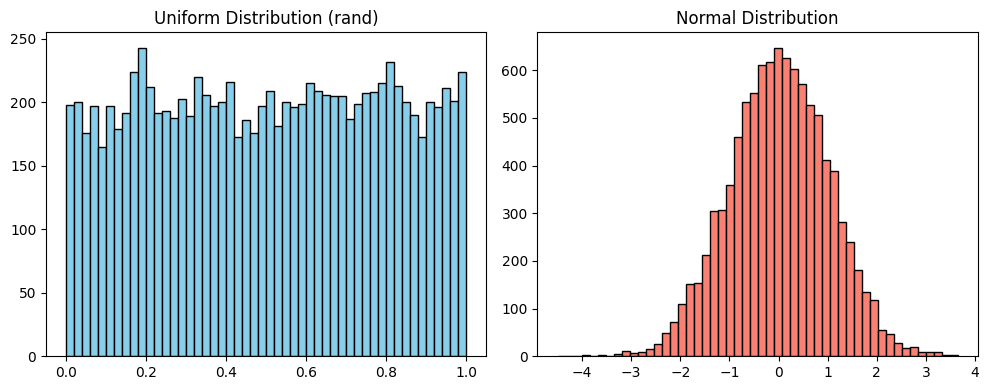

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate samples
uniform_data = np.random.rand(10000)
normal_data = np.random.normal(loc=0, scale=1, size=10000)

uniform = np.random.uniform(0, 1, 10000)
normal = np.random.normal(0, 1, 10000)
poisson = np.random.poisson(5, 10000)
exponential = np.random.exponential(1, 10000)

# Plot
plt.figure(figsize=(10,4))

# Uniform (rand)
plt.subplot(1,2,1)
plt.hist(uniform_data, bins=50, color='skyblue', edgecolor='black')
plt.title("Uniform Distribution (rand)")

# Normal
plt.subplot(1,2,2)
plt.hist(normal_data, bins=50, color='salmon', edgecolor='black')
plt.title("Normal Distribution")

plt.tight_layout()
plt.show()

### 🧠 When to use `rand()` (uniform distribution)
Use `rand()` if:

* Every value should be equally likely
* You just need generic randomness
* You're doing things like:
* Random sampling
* Shuffling
* Generating probabilities

### 🔔 When to use `normal()` (Gaussian distribution)
Use `normal()` if:

* Your data should cluster around a mean
* You want real-world-like variation
* You're modeling:
  * Measurement noise
  * Heights, exam scores
  * Errors in experiments

### Other Distributions:
1. Uniform (Uniform): `np.random.rand()` / `np.random.uniform(a, b)`
2. Normal (Gaussian): `np.random.normal(loc, scale)`
3. Binomial: `np.random.binomial(n, p)`
4. Poisson: 'np.random.poisson(lam)'
5. Exponential: 'np.random.exponential(scale)'
6. Beta: `np.random.beta(a, b)`
7. Gamma: `np.random.gamma(shape, scale)`
8. Chi-square: `np.random.chisquare(df)`
9. Log-normal: `np.random.lognormal(mean, sigma)`


## **1.5. BATCH OF DATA USING NUMPY**

<img src="https://drive.google.com/uc?id=1e6zlchmwG12FPeL4QW3Lo2Eq0W14Ydr4" width="800" alt="numpy_batch_input">

<div class="alert alert-block alert-danger">

NEED TO TAKE TRANSPOSE OF WEIGHT MATRIX</div>

In [ ]:
inputs = np.array([
    [1.0, 2.0, 3.0, 2.5],
    [2.0, 5.0, -1.0, 2.0],
    [-1.5, 2.7, 3.3, -0.8]
])
weights = np.array([
    [0.2, 0.8, -0.5, 1],
    [0.5, -0.91, 0.26, -0.5],
    [-0.26, -0.27, 0.17, 0.87]
])
biases = np.array([2.0, 3.0, 0.5])

# NOTE: WE CAN'T TRANSPOSE LISTS IN PYTHON, SO WE HAVE THE CONVERT THE WEIGHTS MATRIX INTO AN ARRAY FIRST
outputs = np.dot(inputs, weights.T) + biases
print(outputs)

[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]


In [ ]:
inputs = np.array([
    [1.0, 2.0, 3.0, 2.5],
    [2.0, 5.0, -1.0, 2.0],
    [-1.5, 2.7, 3.3, -0.8]
])
weights1 = np.array([
    [0.2, 0.8, -0.5, 1],
    [0.5, -0.91, 0.26, -0.5],
    [-0.26, -0.27, 0.17, 0.87]
])
weights2 = np.array([
    [0.1, -0.14, 0.5],
    [-0.5, 0.12, -0.33],
    [-0.44, 0.73, -0.13]
])
biases1 = np.array([2, 3, 0.5])
biases2 = np.array([-1, 2, -0.5])

 # Activation function (sigmoid)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Calculate the output of the first layer
layer1_inputs = np.dot(inputs, weights1.T) + biases1        # hidden_inputs  = np.dot(inputs, weights1.T) + biases1
layer1_outputs = layer1_inputs                              # hidden_outputs = sigmoid(layer1_inputs)


# Calculate the output of the second layer
layer2_inputs = np.dot(layer1_outputs, weights2.T) + biases2 # final_inputs  = np.dot(layer1_outputs, weights2.T) + biases2
layer2_outputs = layer2_inputs                               # final_outputs = sigmoid(final_inputs)

print(layer2_outputs)

[[ 0.5031  -1.04185 -2.03875]
 [ 0.2434  -2.7332  -5.7633 ]
 [-0.99314  1.41254 -0.35655]]


In [ ]:
!pip install nnfs

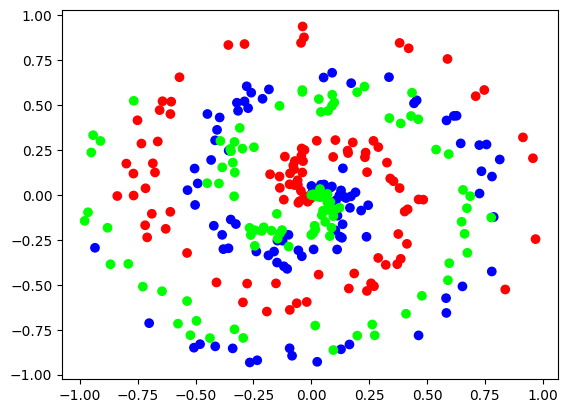

In [ ]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X, y = spiral_data(samples=100, classes=3)
# plt.scatter(X[:, 0], X[:, 1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

In [2]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()

class NeuralNetwork:
  def __init__(self, inputNodes, hiddenNodes, outputNodes, learningRate):
    #self.weights = np.random.normal(0.0, pow(hiddenNodes, -0.5), (hiddenNodes, inputNodes))
    self.weights = 0.01 * np.random.randn(inputNodes, hiddenNodes) # (Input * HiddenNodes) <-- Order Important, otherwise we need to use Transpose
    self.biases = np.zeros((1, hiddenNodes))

  def forward(self, inputs):
    # Calculate output values from inputs, weights and biases
    self.output = np.dot(inputs, self.weights) + self.biases
    pass


# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
nn = NeuralNetwork(2, 3, 0, 0)
# Perform a forward pass of our training data through this layer
nn.forward(X)


# Let's see output of the first few samples:
print(nn.output[:5])

ModuleNotFoundError: No module named 'nnfs'

**ACTIVATION FUNCTION: SOFTMAX**

In [5]:
### TRY THESE EXERCISES FOR YOURSELF!

A = [[1, 2, 3], [4, 5, 6], [7, 8,9]]
print(np.sum(A))

print(np.sum(A, axis = 0))
print(np.sum(A, axis = 0).shape)

print(np.sum(A, axis = 1))
print(np.sum(A, axis = 1).shape)

print(np.sum(A, axis = 0,keepdims = True))
print(np.sum(A, axis = 0,keepdims = True).shape)

print(np.sum(A, axis = 1,keepdims = True))
print(np.sum(A, axis = 1,keepdims = True).shape)

print(np.max(A, axis = 0))
print(np.max(A, axis = 1))

45
[12 15 18]
(3,)
[ 6 15 24]
(3,)
[[12 15 18]]
(1, 3)
[[ 6]
 [15]
 [24]]
(3, 1)
[7 8 9]
[3 6 9]


In [6]:
inputs = [[1, 2, 3, 2.5],
 [2., 5., -1., 2],
 [-1.5, 2.7, 3.3, -0.8]]

# Get unnormalized probabilities
exp_values = np.exp(inputs - np.max(inputs, axis=1,keepdims=True))
 # Normalize them for each sample
probabilities = exp_values / np.sum(exp_values, axis=1,keepdims=True)
print(probabilities)
np.sum(probabilities, axis = 1)

[[0.06414769 0.17437149 0.47399085 0.28748998]
 [0.04517666 0.90739747 0.00224921 0.04517666]
 [0.00522984 0.34875873 0.63547983 0.0105316 ]]


array([1., 1., 1.])

In [ ]:
class Activation_Signmoid:
  def forward(self, inputs):
    self.output = 1 / (1 + np.exp(-inputs))

class Activation_ReLU:
  def forward(self, inputs):
    self.output = np.maximum(0, inputs)

class Activation_Softmax:
  def forward(self, inputs):
    # Get unnormalized probabilities
    exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
    # Normalize them for each sample
    probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
    self.output = probabilities

### EXECUTE ONE COMPLETE FORWARD PASS

In [ ]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
layer1 = NeuralNetwork(2, 3, 0, 0)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()

# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
layer2 = NeuralNetwork(3, 3, 0, 0)
# Create Softmax activation (to be used with Dense layer):
activation2 = Activation_Softmax()

# Make a forward pass of our training data through this layer
layer1.forward(X)

# Make a forward pass through activation function
# it takes the output of first dense layer here
activation1.forward(layer1.output)
# Make a forward pass through second Dense layer
# it takes outputs of activation function of first layer as inputs
layer2.forward(activation1.output)
# Make a forward pass through activation function
# it takes the output of second dense layer here
activation2.forward(layer2.output)
# Let's see output of the first few samples:
print(activation2.output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]
 [0.33333334 0.33333334 0.33333334]]


# **1.6. CALCULATING NETWORK ERROR WITH LOSS**

### **CROSS ENTROPY LOSS BUILDING BLOCKS IN PYTHON**

In [ ]:
softmax_outputs = np.array([
    [0.7, 0.1, 0.2],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])
class_targets = [0, 1, 1]
print(softmax_outputs[[0, 1, 2], class_targets])

[0.7 0.5 0.9]


In [ ]:
print(-np.log(softmax_outputs[
 range(len(softmax_outputs)), class_targets
]))
neg_log = -np.log(softmax_outputs[
 range(len(softmax_outputs)), class_targets
 ])
average_loss = np.mean(neg_log)
print(average_loss)

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


**IF DATA IS ONE HOT ENCODED, HOW TO EXTRACT THE RELEVANT PREDICTIONS**

In [ ]:
y_true_check = np.array([
    [0, 1, 0],
    [1, 0, 0],
    [0, 0, 1]
])

y_pred_clipped_check = np.array([
    [0.2, 0.7, 0.1],
    [0.8, 0.1, 0.1],
    [0.1, 0.2, 0.7]
])

y_true_check*y_pred_clipped_check


array([[0. , 0.7, 0. ],
       [0.8, 0. , 0. ],
       [0. , 0. , 0.7]])

### **IMPLEMENTING THE LOSS CLASS**

In [ ]:
# Common loss class
class Loss:
 # Calculates the data and regularization losses
 # given model output and ground truth values
 def calculate(self, output, y):
  # Calculate sample losses
  sample_losses = self.forward(output, y)
  # Calculate mean loss
  data_loss = np.mean(sample_losses)
  # Return loss
  return data_loss

IMPLEMENTING THE MEAN SQUARE ERROR(MSE)

In [ ]:
class Loss_MeanSquaredError(Loss):
 def forward(self, output, y):
    # s =(np.square(output-y))
    # s = np.sum(s)/len(y)
    # return(s)

    # Return per-sample loss (NOT averaged over all samples)
    return np.mean(np.square(output - y), axis=1)

In [ ]:
# Model predictions
output = np.array([
    [0.8],
    [0.4],
    [0.3]
])

# True values
y = np.array([
    [1.0],
    [0.0],
    [0.0]
])

# Create loss object
loss_function = Loss_MeanSquaredError()

# Get per-sample losses
sample_losses = loss_function.forward(output, y)

# Get final loss
loss = loss_function.calculate(output, y)

print("Sample losses:", sample_losses)
print("Final MSE loss:", loss)

Sample losses: [0.04 0.16 0.09]
Final MSE loss: 0.09666666666666668


IMPLEMENTING THE CATEGORICAL CROSS ENTROPY CLASS

In [26]:
# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
 # Forward pass
 def forward(self, y_pred, y_true):
  # Number of samples in a batch
  samples = len(y_pred)
  # Clip data to prevent division by 0
  # Clip both sides to not drag mean towards any value
  y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
  # Probabilities for target values -
  # only if categorical labels
  if len(y_true.shape) == 1:
   correct_confidences = y_pred_clipped[
   range(samples),
   y_true
   ]
  # Mask values - only for one-hot encoded labels
  elif len(y_true.shape) == 2:
   correct_confidences = np.sum(
   y_pred_clipped*y_true,
   axis=1
   )
 # Losses
  negative_log_likelihoods = -np.log(correct_confidences)
  return negative_log_likelihoods

NameError: name 'Loss' is not defined

In [ ]:
softmax_outputs = np.array([[0.7, 0.1, 0.2],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
class_targets = np.array([[1, 0, 0],
 [0, 1, 0],
 [0, 1, 0]])
loss_function = Loss_CategoricalCrossentropy()
loss = loss_function.calculate(softmax_outputs, class_targets)
print(loss)

0.38506088005216804


FULL CODE UPTO THIS POINT

In [21]:
import numpy as np

activation2_output = np.array([
    [0.33333334, 0.6333334, 0.33333334],
    [0.33333412, 0.3333327,  0.6333313],
    [0.33333495, 0.033332,   0.33333302],
    [0.8333358,  0.3333313,  0.33333293],
    [0.33333617, 0.33333114, 0.9333327]
])


# argmax finds the index of the largest value
# axis=1 means: do it row-wise
predictions = np.argmax(activation2_output, axis=1)
print(predictions)

predictions1 = np.argmax(activation2_output, axis=0)
print(predictions1)

accuracy = np.mean(predictions)
print("accuracy: ",accuracy )

[1 2 0 0 2]
[3 0 4]
accuracy:  1.0


In [ ]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
layer1 = NeuralNetwork(2, 3, 0, 0)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()

# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
layer2 = NeuralNetwork(3, 3, 0, 0)
# Create Softmax activation (to be used with Dense layer):
activation2 = Activation_Softmax()

# Make a forward pass of our training data through this layer
layer1.forward(X)

# Make a forward pass through activation function
# it takes the output of first dense layer here
activation1.forward(layer1.output)
# Make a forward pass through second Dense layer
# it takes outputs of activation function of first layer as inputs
layer2.forward(activation1.output)
# Make a forward pass through activation function
# it takes the output of second dense layer here
activation2.forward(layer2.output)
# Let's see output of the first few samples:
print(activation2.output[:5])


# Create loss function
loss_function = Loss_CategoricalCrossentropy()
# Perform a forward pass through activation function
# it takes the output of second dense layer here and returns loss
loss = loss_function.calculate(activation2.output, y)
# Print loss value
print('loss:', loss)

# Calculate accuracy from output of activation2 and targets
# calculate values along first axis
# argmax finds the index of the largest value
# axis=1 means: do it row-wise
predictions = np.argmax(activation2.output, axis=1)
if len(y.shape) == 2:
 y = np.argmax(y, axis=1)
accuracy = np.mean(predictions == y)
# Print accuracy
print('acc:', accuracy)

[[0.33333334 0.33333334 0.33333334]
 [0.33333412 0.3333327  0.33333313]
 [0.33333495 0.333332   0.33333302]
 [0.3333358  0.3333313  0.33333293]
 [0.33333617 0.33333114 0.3333327 ]]
loss: 1.0986174
acc: 0.31


### **INTRODUCING ACCRUACY**

In [ ]:
import numpy as np
# Probabilities of 3 samples
softmax_outputs = np.array([
    [0.7, 0.2, 0.1],
    [0.5, 0.1, 0.4],
    [0.02, 0.9, 0.08]
])
# Target (ground-truth) labels for 3 samples
class_targets = np.array([0, 1, 1])
# Calculate values along second axis (axis of index 1)
predictions = np.argmax(softmax_outputs, axis=1)
# If targets are one-hot encoded - convert them
if len(class_targets.shape) == 2:
 class_targets = np.argmax(class_targets, axis=1)
# True evaluates to 1; False to 0
accuracy = np.mean(predictions == class_targets)
print('acc:', accuracy)

acc: 0.6666666666666666


### **THE NEED FOR OPTIMIZATION**

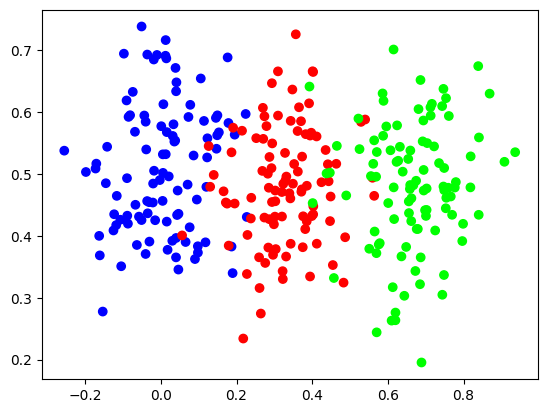

In [24]:
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data
import numpy as np

nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

### **STRATEGY1: RANDOMLY SELECT WEIGHTS AND BIASES - DOES NOT WORK!**

In [25]:
# Create dataset
X, y = vertical_data(samples=100, classes=3)
layer1 = NeuralNetwork(2, 3, 0, 0)
activation1 = Activation_ReLU()
layer2 = NeuralNetwork(3, 3, 0, 0)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalCrossentropy()


# helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = layer1.weights.copy()
best_dense1_biases = layer1.biases.copy
best_dens2_weights = layer2.weights.copy()
best_dens2_biases = layer2.biases.copy()

for iteration in range(10000):
 # Generate a new set of weights for iteration
 layer1.weights = 0.05 * np.random.randn(2, 3)
 layer1.biases = 0.05 * np.random.randn(1, 3)
 layer2.weights = 0.05 * np.random.randn(3, 3)
 layer2.biases = 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of the training data through this layer
 layer1.forward(X)
 activation1.forward(layer1.output)
 activation2.forward(layer2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # if less is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration, 'loss:', loss, 'acc', accuracy)
  best_dense1_weights = layer1.weights.copy()
  best_dense1_biases = layer1.biases.copy()
  best_dens2_weights = layer2.weights.copy()
  best_dens2_biases = layer2.biases.copy()
  lowest_loss = loss

NameError: name 'NeuralNetwork' is not defined

### **STRATEGY 2: RANDOMLY ADJUST WEIGHTS AND BIASES - WORKS!**

In [ ]:
# Create dataset
X, y = vertical_data(samples=100, classes=3)
layer1 = NeuralNetwork(2, 3, 0, 0)
activation1 = Activation_ReLU()
layer2 = NeuralNetwork(3, 3, 0, 0)
activation2 = Activation_Softmax()
loss_function = Loss_CategoricalCrossentropy()


# helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = layer1.weights.copy()
best_dense1_biases = layer1.biases.copy
best_dens2_weights = layer2.weights.copy()
best_dens2_biases = layer2.biases.copy()

for iteration in range(10000):
 # Update weights with some small random value
 layer1.weights += 0.05 * np.random.randn(2, 3)
 layer1.biases += 0.05 * np.random.randn(1, 3)
 layer2.weights += 0.05 * np.random.randn(3, 3)
 layer2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of the training data through this layer
 layer1.forward(X)
 activation1.forward(layer1.output)
 activation2.forward(layer2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # if less is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration, 'loss:', loss, 'acc', accuracy)
  best_dense1_weights = layer1.weights.copy()
  best_dense1_biases = layer1.biases.copy()
  best_dens2_weights = layer2.weights.copy()
  best_dens2_biases = layer2.biases.copy()
  lowest_loss = loss
else:
  layer1.weights = best_dense1_weights.copy()
  layer1.biases = best_dense1_biases.copy()
  layer2.weights = best_dens2_weights.copy()
  layer2.biases = best_dens2_biases
  # print('Iteration:', iteration, 'loss:', loss, 'acc:', accuracy)


## **STRATEGY 2: FOR SPIRAL DATASET - DOES NOT WORK!**

In [ ]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)# Create model
dense1 = NeuralNetwork(2, 3, 0, 0) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = NeuralNetwork(3, 3, 0, 0) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()
# Helper variables
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()
for iteration in range(10000):
 # Update weights with some small random values
 dense1.weights += 0.05 * np.random.randn(2, 3)
 dense1.biases += 0.05 * np.random.randn(1, 3)
 dense2.weights += 0.05 * np.random.randn(3, 3)
 dense2.biases += 0.05 * np.random.randn(1, 3)
 # Perform a forward pass of our training data through this layer
 dense1.forward(X)
 activation1.forward(dense1.output)
 dense2.forward(activation1.output)
 activation2.forward(dense2.output)
 # Perform a forward pass through activation function
 # it takes the output of second dense layer here and returns loss
 loss = loss_function.calculate(activation2.output, y)
 # Calculate accuracy from output of activation2 and targets
 # calculate values along first axis
 predictions = np.argmax(activation2.output, axis=1)
 accuracy = np.mean(predictions == y)
 # If loss is smaller - print and save weights and biases aside
 if loss < lowest_loss:
  print('New set of weights found, iteration:', iteration,'loss:', loss, 'acc:', accuracy)
  best_dense1_weights = dense1.weights.copy()
  best_dense1_biases = dense1.biases.copy()
  best_dense2_weights = dense2.weights.copy()
  best_dense2_biases = dense2.biases.copy()
  lowest_loss = loss
 # Revert weights and biases
 else:
  dense1.weights = best_dense1_weights.copy()
  dense1.biases = best_dense1_biases.copy()
  dense2.weights = best_dense2_weights.copy()
  dense2.biases = best_dense2_biases.copy()

# **CODING BACKPROPAGATION FROM SCRATCH: ON A SINGLE NEURON**

In [ ]:
import numpy as np

# Initial parameters
weights = np.array([-3.0, -1.0, 2.0])
bias = 1.0
inputs = np.array([1.0, -2.0, 3.0])
target_output = 0.0
learning_rate = 0.001

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1.0, 0.0)

for iteration in range(200):
    # Forward pass
    linear_output = np.dot(weights, inputs) + bias
    output = relu(linear_output)
    loss = (output - target_output) ** 2

    # Backward pass
    dloss_doutput = 2 * (output - target_output)
    doutput_dlinear = relu_derivative(linear_output)
    dlinear_dweights = inputs
    dlinear_dbias = 1.0

    dloss_dlinear = dloss_doutput * doutput_dlinear
    dloss_dweights = dloss_dlinear * dlinear_dweights
    dloss_dbias = dloss_dlinear * dlinear_dbias

    # Update weights and bias
    weights -= learning_rate * dloss_dweights
    bias -= learning_rate * dloss_dbias

    # Print the loss for this iteration
    print(f"Iteration {iteration + 1}, Loss: {loss}")

print("Final weights:", weights)
print("Final bias:", bias)


Iteration 1, Loss: 36.0
Iteration 2, Loss: 33.872397424621624
Iteration 3, Loss: 31.87054345809546
Iteration 4, Loss: 29.98699091998773
Iteration 5, Loss: 28.214761511794592
Iteration 6, Loss: 26.54726775906168
Iteration 7, Loss: 24.978326552541866
Iteration 8, Loss: 23.5021050739742
Iteration 9, Loss: 22.11313179151597
Iteration 10, Loss: 20.806246424284897
Iteration 11, Loss: 19.576596334671486
Iteration 12, Loss: 18.41961908608719
Iteration 13, Loss: 17.33101994032309
Iteration 14, Loss: 16.306757070164853
Iteration 15, Loss: 15.343027506224132
Iteration 16, Loss: 14.436253786815284
Iteration 17, Loss: 13.583071280700132
Iteration 18, Loss: 12.780312744165439
Iteration 19, Loss: 12.024995767388878
Iteration 20, Loss: 11.314319082257104
Iteration 21, Loss: 10.64564263994962
Iteration 22, Loss: 10.016485041642266
Iteration 23, Loss: 9.424510031713222
Iteration 24, Loss: 8.867521365009814
Iteration 25, Loss: 8.34345204094211
Iteration 26, Loss: 7.850353118483743
Iteration 27, Loss: 7.3

## **BACKPROPAGATION**

GRADIENTS OF THE LOSS WITH RESPECT TO WEIGHTS

In [ ]:
import numpy as np
# Passed-in gradient from the next layer
# for the purpose of this example we're going to use
# an array of an incremental gradient values
dvalues = np.array([
    [1., 1., 1.],
    [2., 2., 2.],
    [3., 3., 3.]
])
# We have 3 sets of inputs - samples
inputs = np.array([
    [1, 2, 3, 2.5],
    [2., 5., -1., 2],
    [-1.5, 2.7, 3.3, -0.8]
])
# sum weights of given input
# and multiply by the passed-in gradient for this neuron
dweights = np.dot(inputs.T, dvalues)
print(dweights)

[[ 0.5  0.5  0.5]
 [20.1 20.1 20.1]
 [10.9 10.9 10.9]
 [ 4.1  4.1  4.1]]


GRADIENTS OF THE LOSS WITH RESPECT TO BIASES

In [2]:
import numpy as np
# Passed-in gradient from the next layer
# for the purpose of this example we're going to use
# an array of an incremental gradient values
dvalues = np.array([[1., 1., 1.],
 [2., 2., 2.],
 [3., 3., 3.]])
# One bias for each neuron
# biases are the row vector with a shape (1, neurons)
biases = np.array([[2, 3, 0.5]])
# dbiases - sum values, do this over samples (first axis), keepdims
# since this by default will produce a plain list -
# we explained this in the chapter 4
dbiases = np.sum(dvalues, axis=0, keepdims=True)
print(dbiases)

[[6. 6. 6.]]


GRADIENTS OF THE LOSS WITH RESPECT TO INPUTS

In [3]:
import numpy as np
# Passed-in gradient from the next layer
# for the purpose of this example we're going to use
# an array of an incremental gradient values
dvalues = np.array([[1., 1., 1.],
 [2., 2., 2.],
 [3., 3., 3.]])
# We have 3 sets of weights - one set for each neuron
# we have 4 inputs, thus 4 weights
# recall that we keep weights transposed
weights = np.array([[0.2, 0.8, -0.5, 1],
 [0.5, -0.91, 0.26, -0.5],
 [-0.26, -0.27, 0.17, 0.87]]).T
# sum weights of given input
# and multiply by the passed-in gradient for this neuron
dinputs = np.dot(dvalues, weights.T)
print(dinputs)

[[ 0.44 -0.38 -0.07  1.37]
 [ 0.88 -0.76 -0.14  2.74]
 [ 1.32 -1.14 -0.21  4.11]]


ADDING THE "BACKWARD" METHOD IN THE LAYER-DENSE CLASS

In [4]:
# class Layer_Dense:
#  ...
#  # Backward pass
#  def backward(self, dvalues):
#  # Gradients on parameters
#  self.dweights = np.dot(self.inputs.T, dvalues)
#  self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
#  # Gradient on values
#  self.dinputs = np.dot(dvalues, self.weights.T)

ADDING THE "BACKWARD" METHOD IN THE RELU ACTIVATION CLASS

In [ ]:
# # ReLU activation
# class Activation_ReLU:
#  # Forward pass
#  def forward(self, inputs):
#  # Remember input values
#  self.inputs = inputs
#  self.output = np.maximum(0, inputs)
#  # Backward pass
#  def backward(self, dvalues):
#  # Since we need to modify the original variable,
#  # let's make a copy of the values first
#  self.dinputs = dvalues.copy()
#  # Zero gradient where input values were negative
#  self.dinputs[self.inputs <= 0] = 0

LOSS FUNCTION BACKPROPAGATION

In [ ]:
# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
 ...
 # Backward pass
 def backward(self, dvalues, y_true):
 # Number of samples
 samples = len(dvalues)
 # Number of labels in every sample
 # We'll use the first sample to count them
 labels = len(dvalues[0])
 # If labels are sparse, turn them into one-hot vector
 if len(y_true.shape) == 1:
 y_true = np.eye(labels)[y_true]
 # Calculate gradient
 self.dinputs = -y_true / dvalues
 # Normalize gradient
 self.dinputs = self.dinputs / samples

## Creates the two link weight matrices

In [ ]:
# Link weight matrices,  wih(W_input_hidden), who(W_hidden_output)
# weights inside the arrays are w_i_j, where link is from node i to node j in the next layer
# w11 w21
# w12 w22 etc
self.wih = (numpy.random.rand(self.hnodes, self.inodes)  0.5)
self.who = (numpy.random.rand(self.onodes, self.hnodes)  0.5)


self.wih = numpy.random.normal(0.0, pow(self.hnodes, -0.5), (self.hnodes, self.inodes)
self.who = numpy.random.normal(0.0, pow(self.onodes, -0.5), (self.onodes, self.hnodes)

<div align="center">

$\mathbf{X}_{hidden} = \mathbf{W}_{input\_hidden} \cdot \mathbf{I}$

</div>

In [ ]:
hidden_inputs = numpy.dot(self.wih, inputs)

<div style="text-align: center;">

$$
\mathbf{O}_{hidden} = \mathrm{sigmoid}(\mathbf{X}_{hidden})
$$

</div>

In [ ]:
# scipy.special for the sigmoid function expit()
import scipy.special

# activation function is the sigmoid function
self.activation_function = lambda​x: scipy.special.expit(x)

In [ ]:
# calculate the signals emerging from hidden layer
hidden_outputs = self.activation_function(hidden_inputs)

In [ ]:
# calculate signals into hidden layer
hidden_inputs = numpy.dot(self.wih, inputs)
# calculate the signals emerging from hidden layer
hidden_outputs = self.activation_function(hidden_inputs)

# calculate signals into final output layer
final_inputs = numpy.dot(self.who, hidden_outputs)
# calculate the signals emerging from final output layer
final_outputs = self.activation_function(final_inputs)

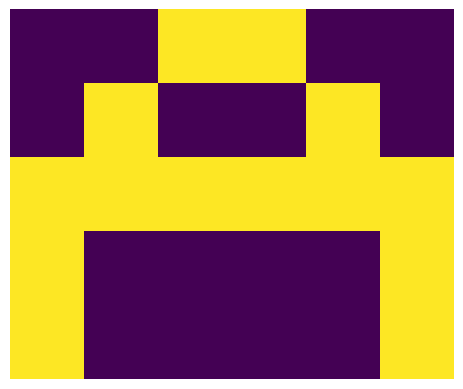

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

a =[0, 0, 1, 1, 0, 0,
    0, 1, 0, 0, 1, 0,
    1, 1, 1, 1, 1, 1,
    1, 0, 0, 0, 0, 1,
    1, 0, 0, 0, 0, 1]


# visualizing the data, plotting A.
plt.imshow(np.array(a).reshape(5, 6))
plt.show()